# Correlation Analysis (A) - Bonn EEG Dataset

## Objective
Identify multicollinearity (redundancy) among extracted features. If two features are highly correlated (e.g., > 0.95 or > 0.99), they provide similar information to the model.

## Features Analyzed
- **Time Domain:** RMS, ZCR
- **Hjorth Parameters:** Activity, Mobility, Complexity
- **Envelope:** Mean, Max
- **Derivatives:** Mean/Std of 1st and 2nd derivatives


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 10)

## 1. Load Data
We use the **Training Set** to analyze feature correlations, as this is what the model sees.

In [2]:
# Load Training Data
data_path = '../data/processed/Bonn_EEG_Train.csv'

if not os.path.exists(data_path):
    print("Data file not found! Please run scripts/generate_dataset.py first.")
else:
    df = pd.read_csv(data_path)
    print(f"Data loaded: {df.shape}")

Data loaded: (26312, 192)


## 2. Select Features
We focus only on the extracted features, ignoring raw time-series columns (`X1`...`X178`) and labels.

In [3]:
feature_cols = [
    'RMS', 'ZCR', 
    'Hjorth_Activity', 'Hjorth_Mobility', 'Hjorth_Complexity',
    'Envelope_Mean', 'Envelope_Max', 
    'Deriv1_Mean', 'Deriv1_Std', 
    'Deriv2_Mean', 'Deriv2_Std'
]

# Verify columns exist
available_cols = [c for c in feature_cols if c in df.columns]
print(f"Features found: {len(available_cols)}/{len(feature_cols)}")

df_features = df[available_cols]
df_features.head()

Features found: 11/11


,RMS,ZCR,Hjorth_Activity,Hjorth_Mobility,Hjorth_Complexity,Envelope_Mean,Envelope_Max,Deriv1_Mean,Deriv1_Std,Deriv2_Mean,Deriv2_Std
0,457.953774,0.050562,209710.270768,0.272722,1.860492,582.193495,1445.495922,-5.514306,124.890462,-0.990711,63.368947
1,51.629563,0.056180,2412.341001,0.276402,2.655629,63.455155,150.164260,0.030037,13.575642,-0.205156,9.964806
2,42.381231,0.044944,1795.857267,0.172209,3.433867,55.491135,106.408327,-0.131628,7.297809,-0.014674,4.315514
3,49.511076,0.061798,1775.156474,0.205171,2.695873,58.087050,136.483419,0.493691,8.644401,-0.042599,4.781354
4,18.224970,0.067416,218.565135,0.330265,2.123291,21.341041,48.508368,-0.135126,4.882628,0.041555,3.423942


## 3. Compute Correlation Matrix
We use Pearson correlation coefficient.

In [4]:
corr_matrix = df_features.corr()
corr_matrix

,RMS,ZCR,Hjorth_Activity,Hjorth_Mobility,Hjorth_Complexity,Envelope_Mean,Envelope_Max,Deriv1_Mean,Deriv1_Std,Deriv2_Mean,Deriv2_Std
RMS,1.000000,-0.034939,0.954027,0.081970,-0.180822,0.996537,0.970837,0.018801,0.934836,0.025273,0.879735
ZCR,-0.034939,1.000000,0.012573,0.687628,-0.560314,-0.019327,-0.025646,0.001671,0.154838,-0.001005,0.182152
Hjorth_Activity,0.954027,0.012573,1.000000,0.096067,-0.178652,0.950037,0.930529,0.022363,0.921359,0.037742,0.868676
Hjorth_Mobility,0.081970,0.687628,0.096067,1.000000,-0.804504,0.075644,0.079752,0.003435,0.281194,0.010183,0.333986
Hjorth_Complexity,-0.180822,-0.560314,-0.178652,-0.804504,1.000000,-0.180660,-0.158282,-0.006116,-0.314618,-0.003160,-0.305456
Envelope_Mean,0.996537,-0.019327,0.950037,0.075644,-0.180660,1.000000,0.955835,0.016978,0.929675,0.021733,0.870458
Envelope_Max,0.970837,-0.025646,0.930529,0.079752,-0.158282,0.955835,1.000000,0.019566,0.913940,0.030562,0.874217
Deriv1_Mean,0.018801,0.001671,0.022363,0.003435,-0.006116,0.016978,0.019566,1.000000,0.018184,0.004524,0.014502
Deriv1_Std,0.934836,0.154838,0.921359,0.281194,-0.314618,0.929675,0.913940,0.018184,1.000000,0.041702,0.983936
Deriv2_Mean,0.025273,-0.001005,0.037742,0.010183,-0.003160,0.021733,0.030562,0.004524,0.041702,1.000000,0.050231


## 4. Heatmap Visualization
Visualizing the correlation matrix.

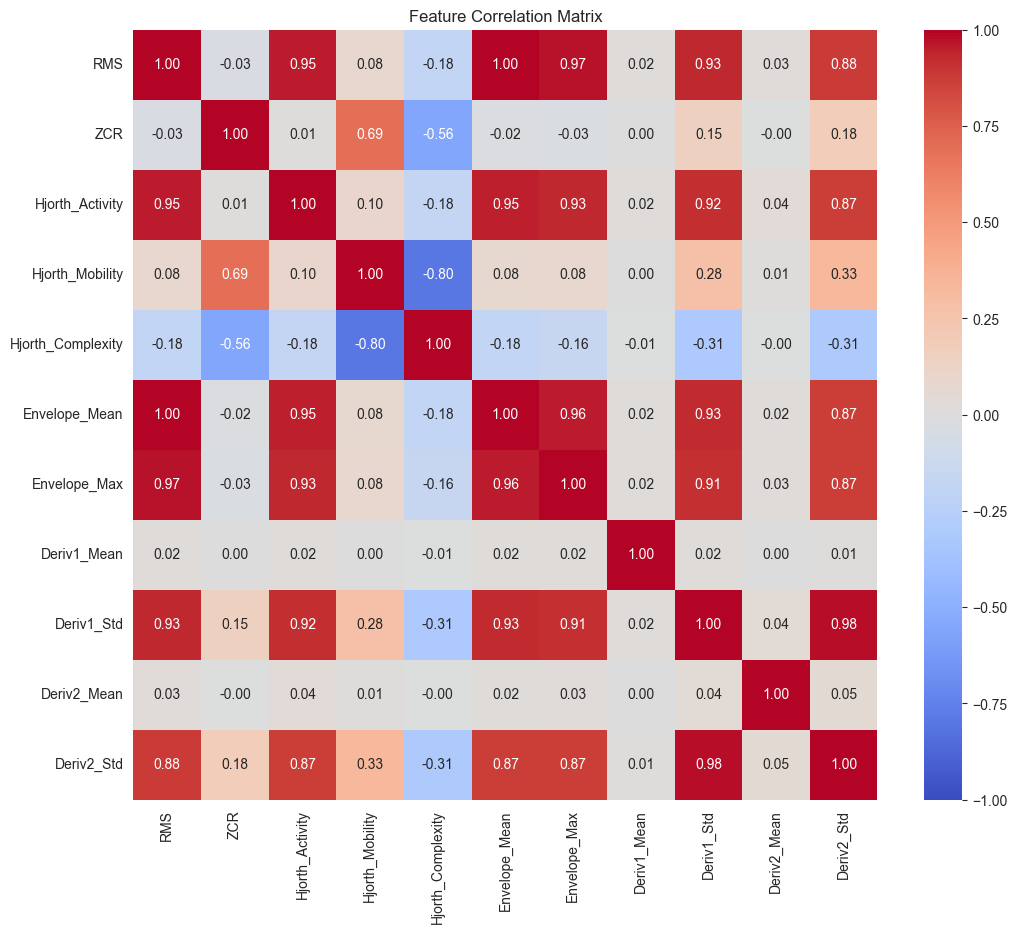

In [5]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix')
plt.show()

## 5. Analysis of Multicollinearity
Listing pairs with correlation > 0.95.

In [6]:
# Find high correlations
threshold = 0.95
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > threshold:
            pair = (corr_matrix.columns[i], corr_matrix.columns[j], val)
            high_corr_pairs.append(pair)

if high_corr_pairs:
    print(f"High correlations (> {threshold}):")
    for p in high_corr_pairs:
        print(f"  {p[0]} <-> {p[1]}: {p[2]:.4f}")
else:
    print("No high correlations found.")

High correlations (> 0.95):
  RMS <-> Hjorth_Activity: 0.9540
  RMS <-> Envelope_Mean: 0.9965
  RMS <-> Envelope_Max: 0.9708
  Hjorth_Activity <-> Envelope_Mean: 0.9500
  Envelope_Mean <-> Envelope_Max: 0.9558
  Deriv1_Std <-> Deriv2_Std: 0.9839
